In [1]:
import os
import pandas as pd
import logging
from sqlalchemy import create_engine
import numpy as np

In [2]:
engine = create_engine("sqlite:///project.db")

In [3]:
import sqlite3
import pandas as pd

# open a new connection
conn = sqlite3.connect("project.db")

# now run your query
df = pd.read_sql_query("SELECT * FROM vendor_sales_summary", conn)





In [4]:
pd.read_sql_query("Select * from  vendor_sales_summary ",conn)

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,5101919.51,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4819073.49,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,4538120.60,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,4475972.88,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,4223107.62,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10687,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,4.99,750.0,2,2.64,5.0,15.95,10.96,0.55,27100.41,13.31,83.448276,2.500000,6.041667
10688,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50.0,6,2.34,134.0,65.66,1.47,7.04,50293.62,63.32,96.436186,22.333333,28.059829
10689,3924,HEAVEN HILL DISTILLERIES,9123,Deep Eddy Vodka,0.74,0.99,50.0,2,1.48,2.0,1.98,0.99,0.10,14069.87,0.50,25.252525,1.000000,1.337838
10690,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.47,1.99,200.0,1,1.47,72.0,143.28,77.61,15.12,257032.07,141.81,98.974037,72.000000,97.469388


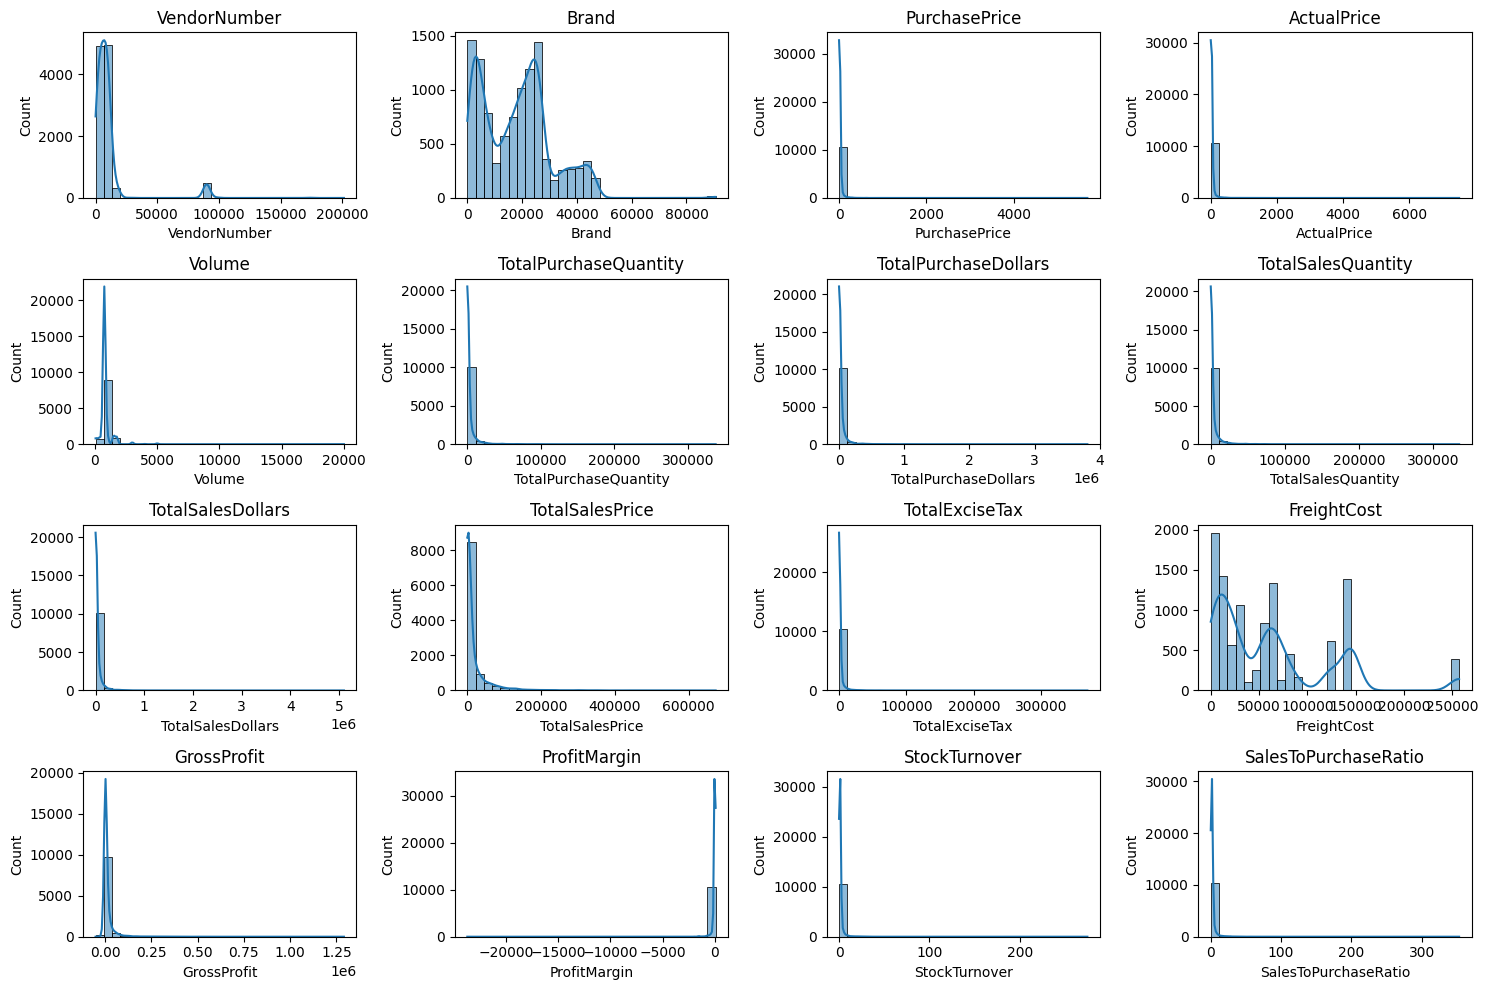

In [5]:
# Distribution Plots for Numerical Columns
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):#enumerate we used for index its special python function that will give you index
    plt.subplot(4, 4, i+1)  # Adjust grid layout as needed
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()


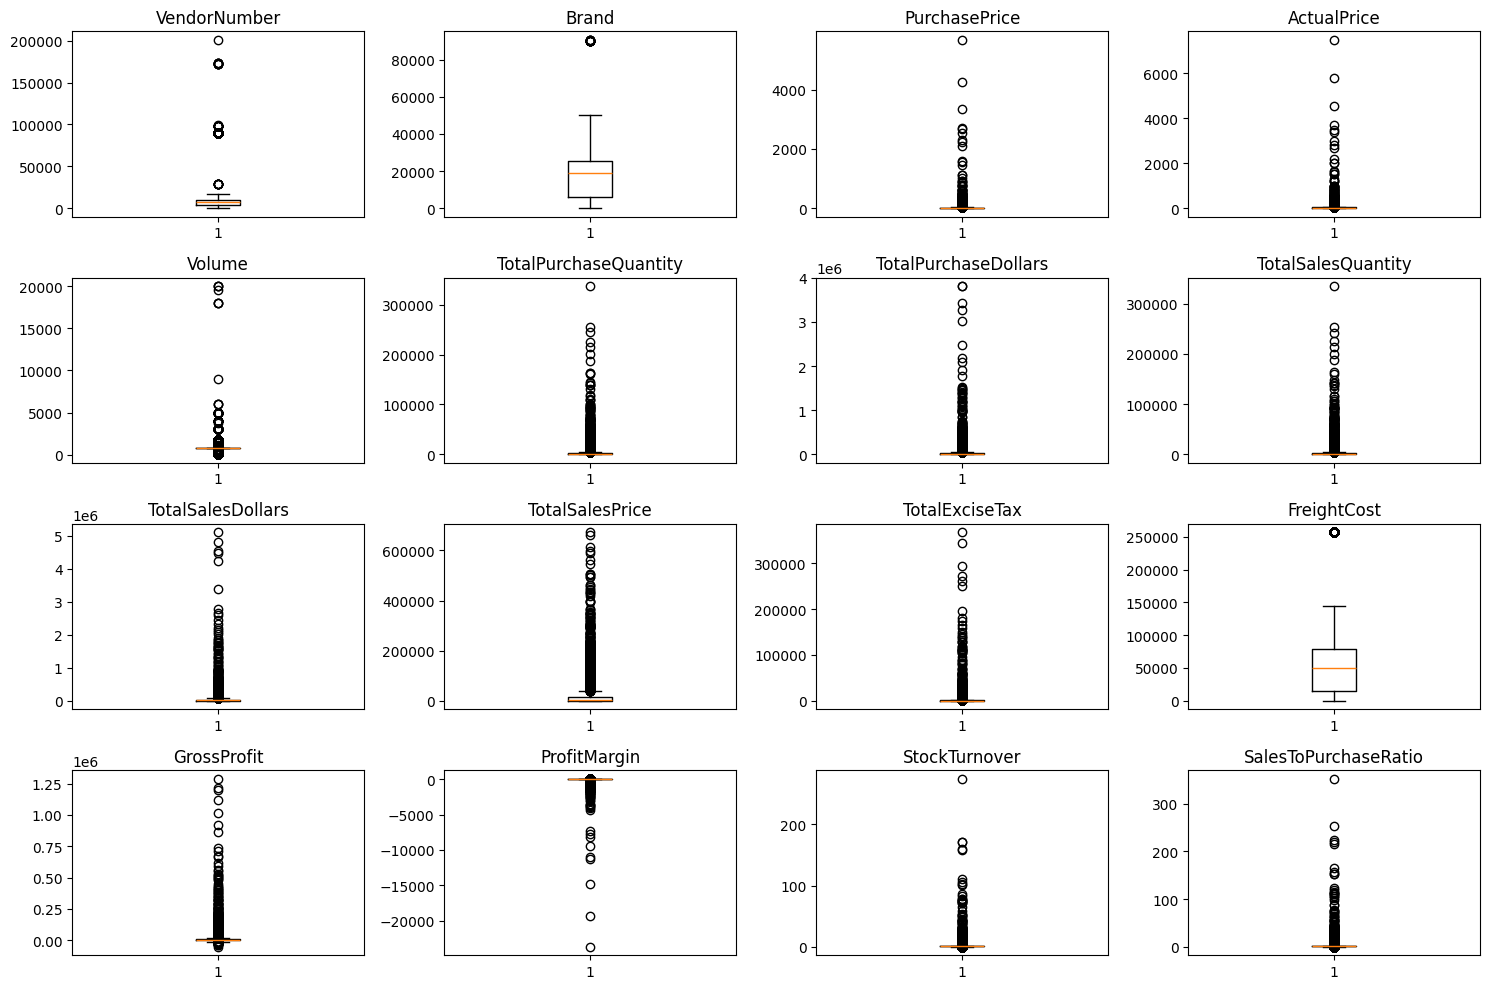

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

numeric_col=df.select_dtypes(include=np.number).columns
plt.figure(figsize=(15,10))
for i,col in enumerate(numeric_col):
    plt.subplot(4,4,i+1)
    plt.boxplot(df[col])
    plt.title(col)
plt.tight_layout()
plt.show()


### Summary Statistics Insights:

#### Negative & Zero Values:

* Gross Profit: Minimum value is -52,002.78, indicating losses. Some products or transactions may be selling at a loss due to high costs or selling at discounts lower than the purchase price.

* Profit Margin: Has a minimum of -∞, which suggests cases where revenue is zero or even lower than costs.

* Total Sales Quantity & Sales Dollars: Minimum values are 0, meaning some products were purchased but never sold. These could be slow-moving or obsolete stock.

#### Outliers Indicated by High Standard Deviations:

* Purchase & Actual Prices: The max values (5,681.81 & 7,499.99) are significantly higher than the mean (24.39 & 35.64), indicating potential premium products.

* Freight Cost: Huge variation, from 0.09 to 257,032.07, suggests logistics inefficiencies or bulk shipments.

* Stock Turnover: Ranges from 0 to 274.5, implying some products sell extremely fast while others remain in stock indefinitely. Value more than 1 indicates that sold quantity for that product is higher than purchased quantity due to either sales are being fulfilled from older stock.

In [6]:
df=pd.read_sql_query("""
SELECT DISTINCT * FROM vendor_sales_summary WHERE  GrossProfit >0 and ProfitMargin>0 and TotalSalesQuantity>0""",conn)

In [7]:
from sqlalchemy import inspect

inspector = inspect(engine)      # yahan engine = tumhara DB connection
print(inspector.get_table_names())


['begin_inventory', 'end_inventory', 'purchase_prices', 'purchases', 'sales', 'vendor_invoice', 'vendor_sales_summary']


In [1]:
df.describe().T

NameError: name 'df' is not defined

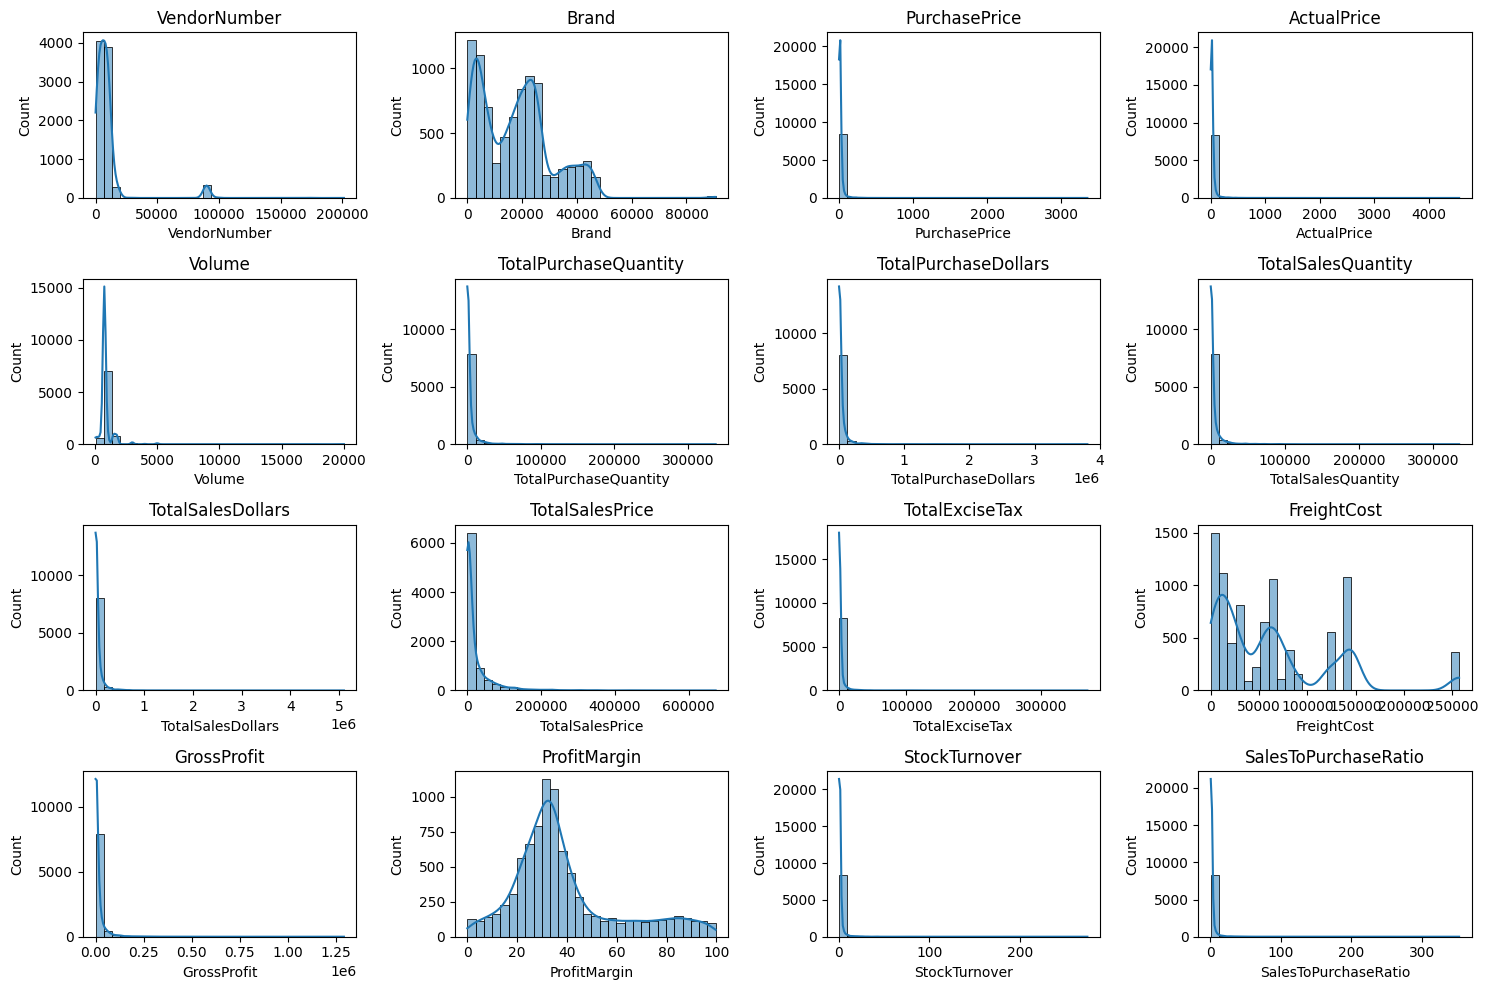

In [9]:
# Distribution Plots for Numerical Columns
import matplotlib.pyplot as plt
import seaborn as sns


numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):#enumerate we used for index its special python function that will give you index
    plt.subplot(4, 4, i+1)  # Adjust grid layout as needed
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()


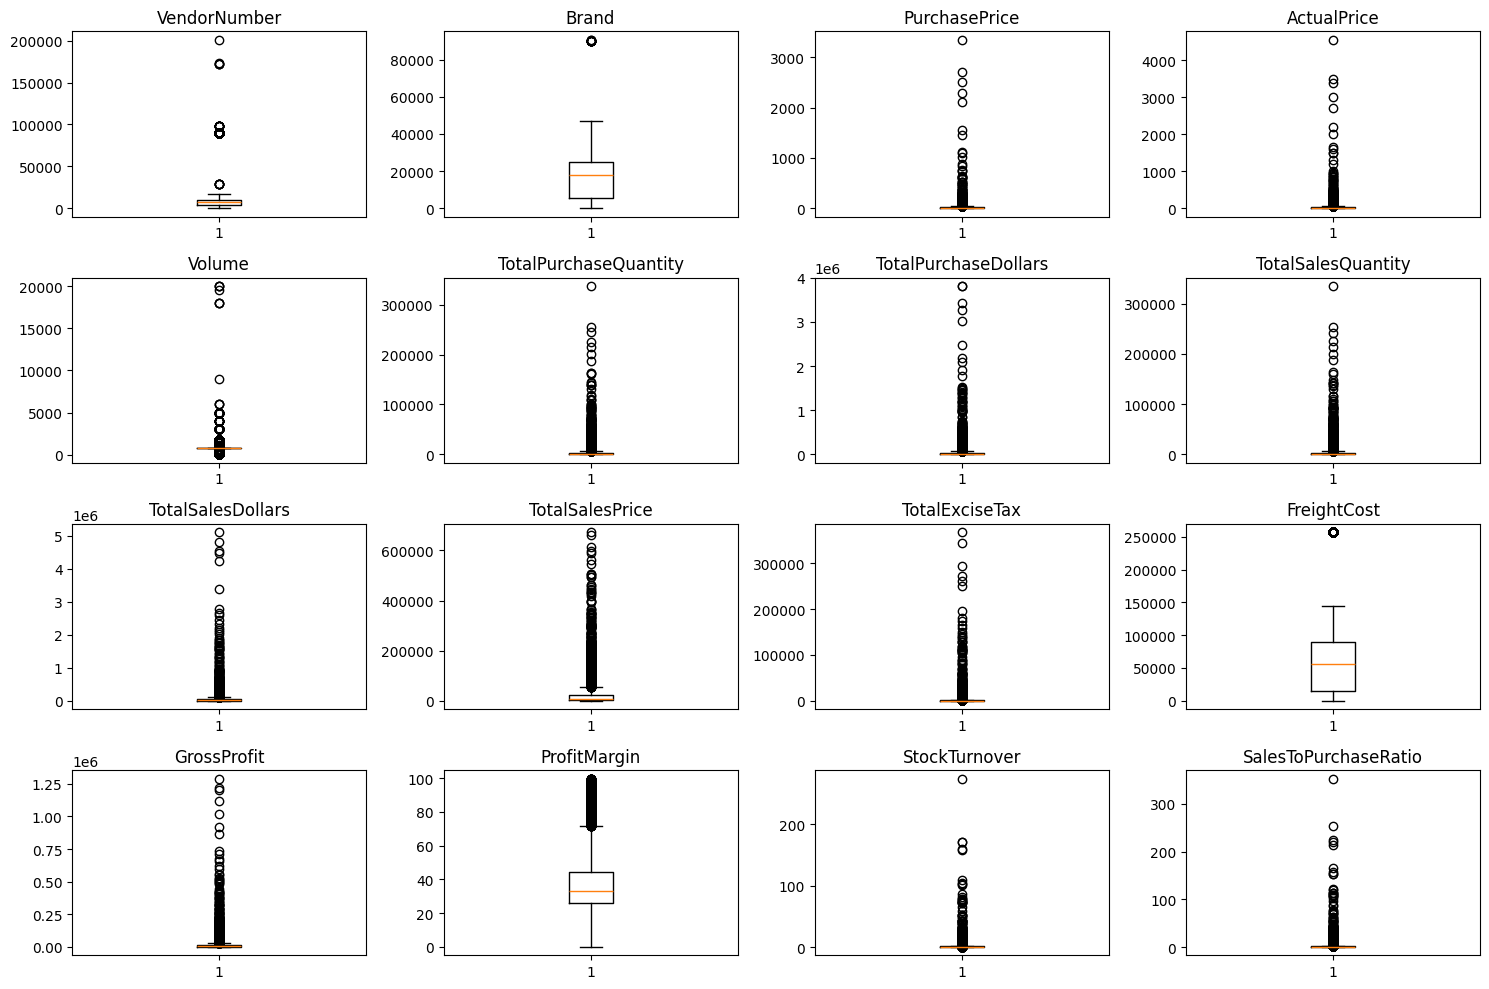

In [226]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

numeric_col=df.select_dtypes(include=np.number).columns
plt.figure(figsize=(15,10))
for i,col in enumerate(numeric_col):
    plt.subplot(4,4,i+1)
    plt.boxplot(df[col])
    plt.title(col)
plt.tight_layout()
plt.show()


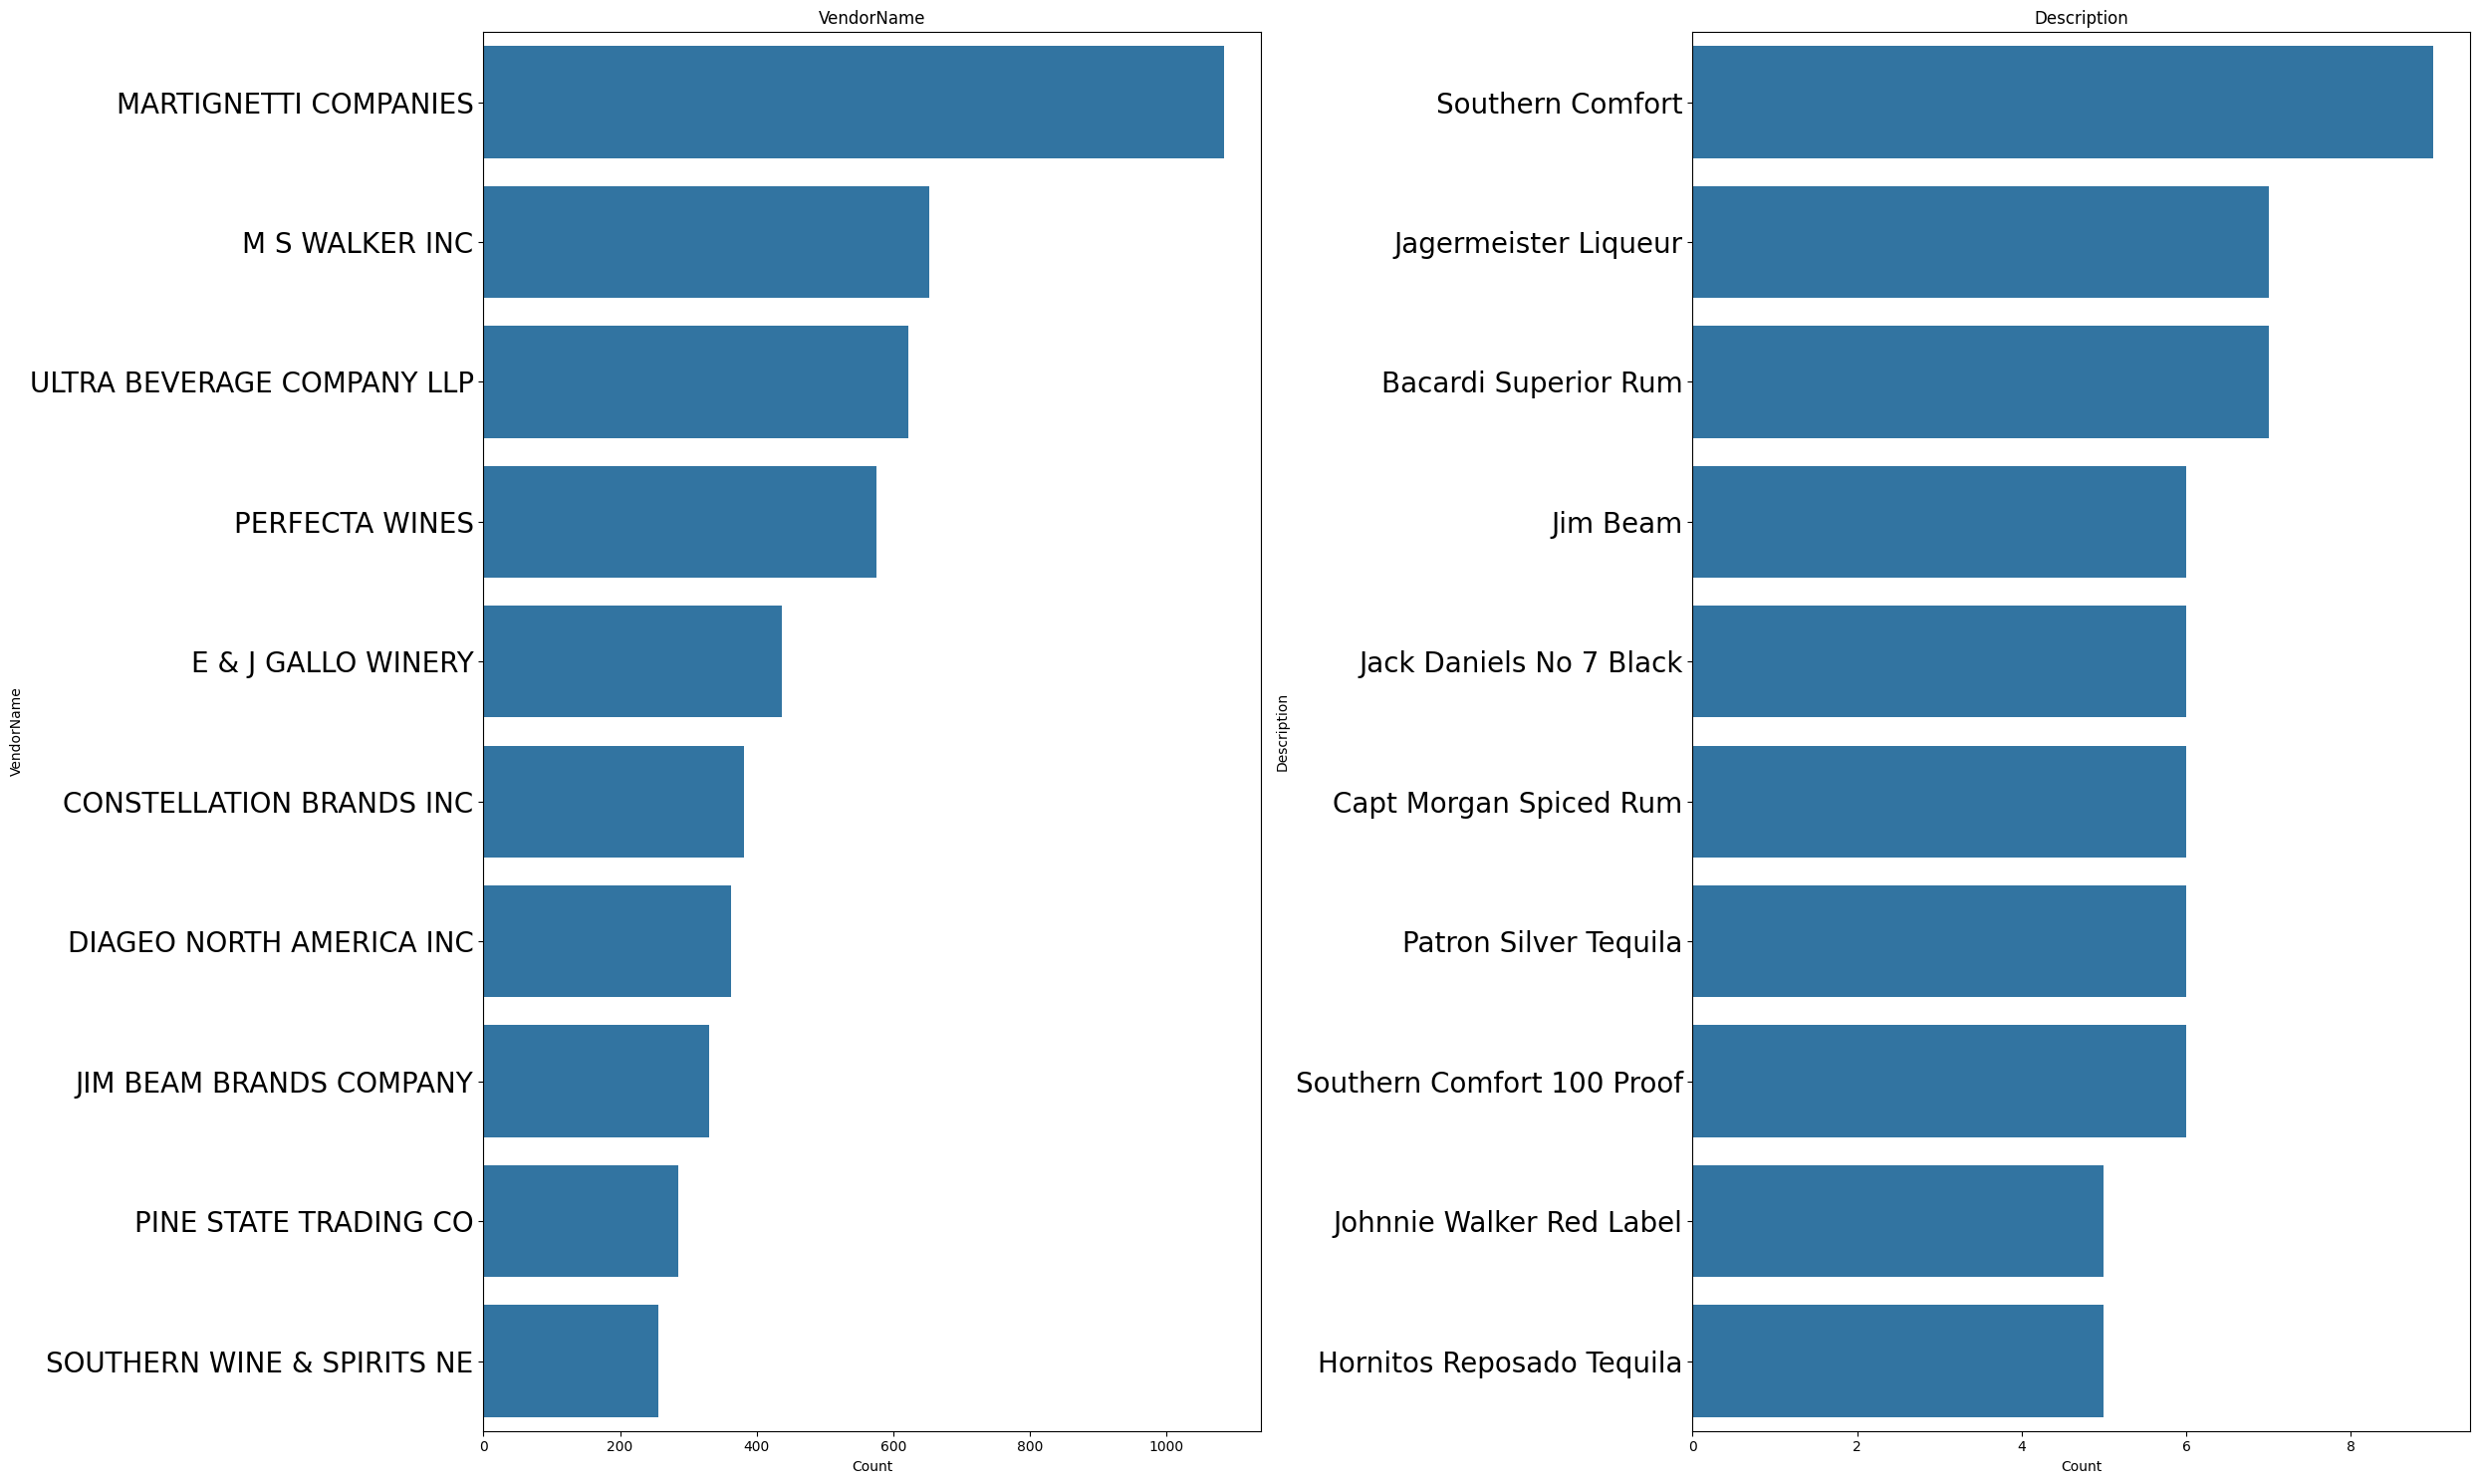

In [10]:
colmn=["VendorName","Description"]
plt.figure(figsize=(25,15))
for i,col in enumerate(colmn):
    plt.subplot(1,2,i+1)
    ax=sns.countplot(y=df[col], order=df[col].value_counts().index[:10])
    plt.xlabel('Count', color='black')        # x-axis label dark
    plt.ylabel(col, color='black')            # y-axis label dark
    ax.tick_params(axis='x', colors='black')  # x-axis tick labels dark
    ax.tick_params(axis='y', colors='black',labelsize=20)  #
    plt.title(col)
plt.tight_layout()
plt.show()

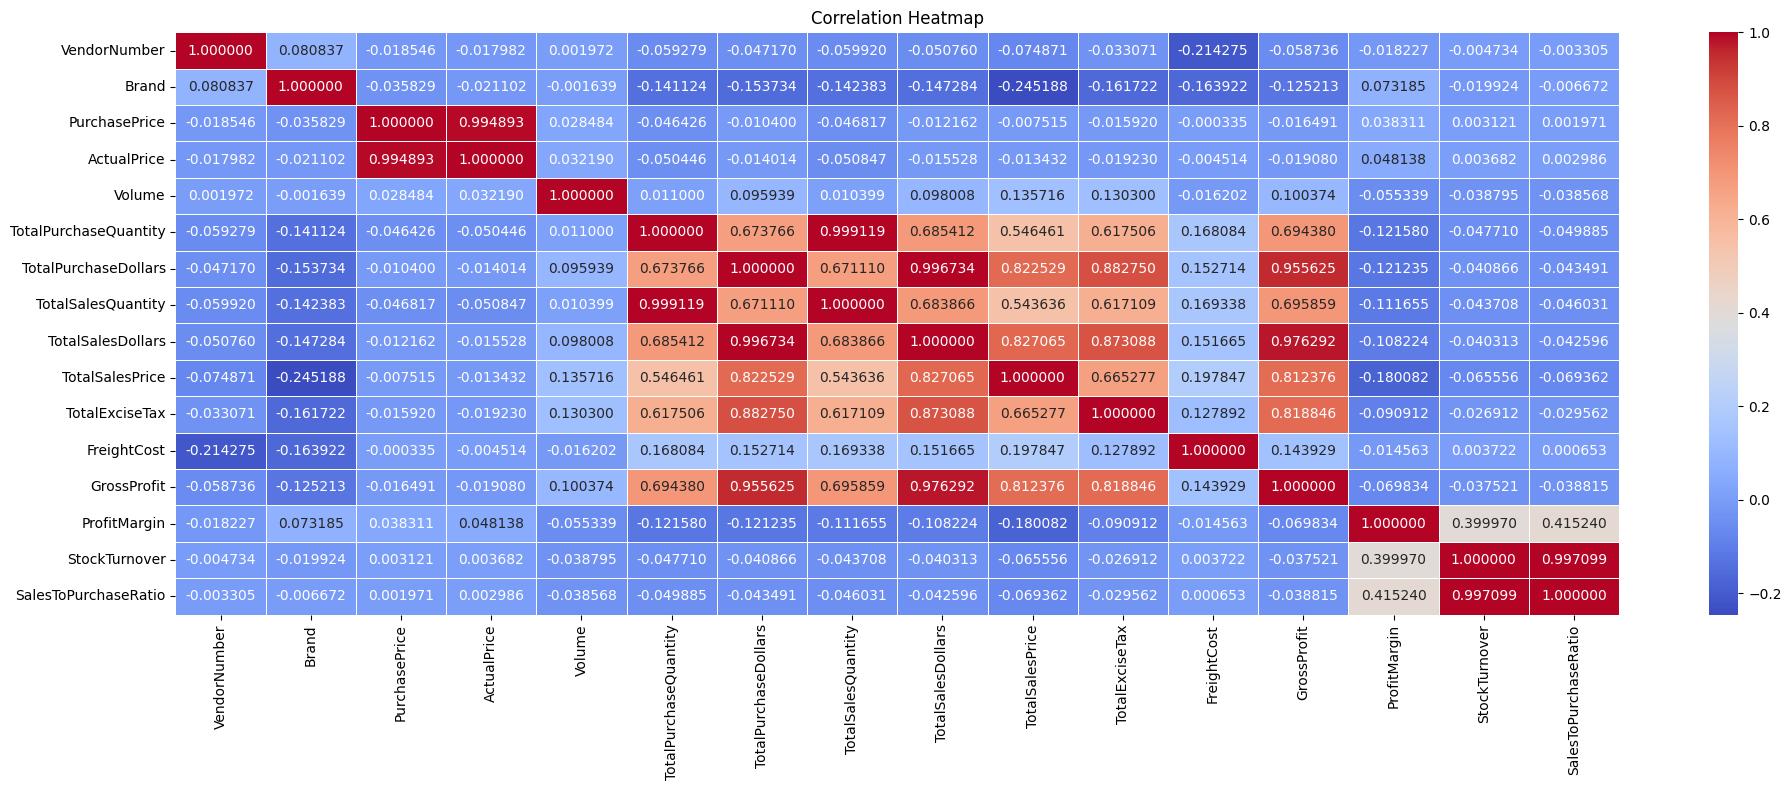

In [11]:
import numpy as np
plt.figure(figsize=(20,8))
numeric_col=(df.select_dtypes(include=np.number)).columns
corelation_amtrix=df[numeric_col].corr()
sns.heatmap(corelation_amtrix, annot=True ,fmt='2f',cmap='coolwarm',linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

### Correlation Insights

* PurchasePrice has weak correlations with TotalSalesDollars (-0.012) and GrossProfit (-0.016), suggesting that * price variations do not significantly impact sales revenue or profit.

* Strong correlation between total purchase quantity and total sales quantity (0.999), confirming efficient inventory turnover.

* Negative correlation between profit margin & total sales price (-0.179) suggests that as sales price increases, margins decrease, possibly due to competitive pricing pressures.

* StockTurnover has weak negative correlations with both GrossProfit (-0.038) and ProfitMargin (-0.055), indicating that faster turnover does not necessarily result in higher profitability.

## Data Analysis

**identify brands that needs apromotional or pricing adjustments which exhibit lower sales performance but higher profit margins**

In [12]:
brand_performance=df.groupby("Description").agg({'TotalSalesDollars':'sum','ProfitMargin':'mean'}).reset_index()

In [13]:
low_sales_threshold= brand_performance["TotalSalesDollars"].quantile(0.15)
high_profite_margin_threshold=brand_performance["ProfitMargin"].quantile(0.85)

In [15]:
low_sales_threshold

np.float64(560.299)

In [14]:
high_profite_margin_threshold

np.float64(64.97017552750113)

In [15]:
target_brands = brand_performance[
    (brand_performance["TotalSalesDollars"] <= low_sales_threshold) &
    (brand_performance["ProfitMargin"] >= high_profite_margin_threshold) 
]


In [16]:
target_brands

,Description,TotalSalesDollars,ProfitMargin
6,12 Days of Pearls Gift Set,309.69,97.678323
45,4 Orange Vodka,483.78,85.902683
57,A Bichot Clos Marechaudes,539.94,67.740860
59,A Bichot Merc Champs M,515.88,94.552997
96,Absolut Orient Apple Vodka,119.94,87.652159
...,...,...,...
7588,Woodford Rsv Master Coll Pnt,489.95,73.760588
7663,Zardetto Pros di Coneg Brut,345.86,88.758457
7677,Zerran Tinto Montsant,139.91,77.592738
7686,Zhenka Vodka 80 Proof,240.39,87.303964


In [18]:
brand_performance= brand_performance[brand_performance["TotalSalesDollars"] < 10000]



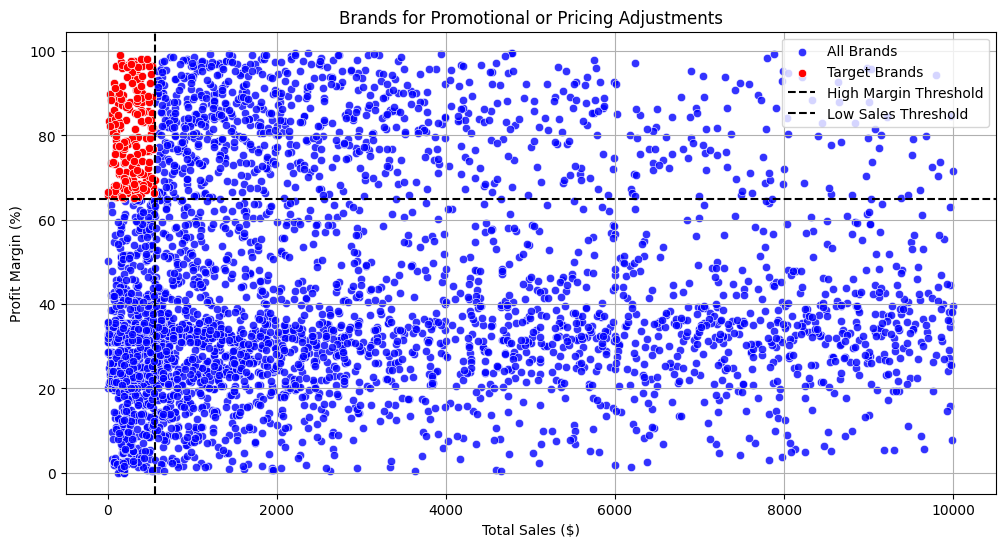

In [19]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=brand_performance, x='TotalSalesDollars', y='ProfitMargin', color='blue', label="All Brands", alpha=0.8)
sns.scatterplot(data=target_brands, x='TotalSalesDollars', y='ProfitMargin', color='red', label="Target Brands")

plt.axhline(high_profite_margin_threshold, linestyle='--', color='black', label='High Margin Threshold')
plt.axvline(low_sales_threshold, linestyle='--', color='black', label='Low Sales Threshold')

plt.xlabel("Total Sales ($)")
plt.ylabel("Profit Margin (%)")
plt.title("Brands for Promotional or Pricing Adjustments")
plt.legend()
plt.grid(True)
plt.show()


#### Whhich Vendors and Brand Demonstarte the highest sales Performance ?

In [20]:
top_vendors= df.groupby("VendorName")["TotalSalesDollars"].sum().nlargest(10)
top_brands=df.groupby("Description")["TotalSalesDollars"].sum().nlargest(10)

In [22]:
top_brands

Description
Jack Daniels No 7 Black    7964746.76
Tito's Handmade Vodka      7399657.58
Grey Goose Vodka           7209608.06
Capt Morgan Spiced Rum     6356320.62
Absolut 80 Proof           6244752.03
Jameson Irish Whiskey      5715759.69
Ketel One Vodka            5070083.56
Baileys Irish Cream        4150122.07
Kahlua                     3604858.66
Tanqueray                  3456697.90
Name: TotalSalesDollars, dtype: float64

In [21]:
top_vendors

VendorName
DIAGEO NORTH AMERICA INC      67990099.42
MARTIGNETTI COMPANIES         39330359.36
PERNOD RICARD USA             32063196.19
JIM BEAM BRANDS COMPANY       31423020.46
BACARDI USA INC               24854817.14
CONSTELLATION BRANDS INC      24218745.65
E & J GALLO WINERY            18399899.46
BROWN-FORMAN CORP             18247230.65
ULTRA BEVERAGE COMPANY LLP    16502544.31
M S WALKER INC                14706458.51
Name: TotalSalesDollars, dtype: float64

In [137]:
#top_vendors=df.groupby("VendorName").agg({"TotalSalesDollars":"sum" }).nlargest(10,"TotalSalesDollars")

In [138]:
#top_brands=df.groupby("Description").agg({"TotalSalesDollars":"sum"}).nlargest(10,"TotalSalesDollars")

In [23]:
def format_dollars(value):
    if value >= 1_000_000:
        # 1 million or more → show in millions
        return f"{value / 1_000_000:.2f}M"
    elif value >= 1_000:
        # 1 thousand or more → show in thousands
        return f"{value / 1_000:.2f}K"
    else:
        # less than 1K → just show the number as is
        return str(value)


In [24]:
top_brands.apply(lambda x : format_dollars(x))


Description
Jack Daniels No 7 Black    7.96M
Tito's Handmade Vodka      7.40M
Grey Goose Vodka           7.21M
Capt Morgan Spiced Rum     6.36M
Absolut 80 Proof           6.24M
Jameson Irish Whiskey      5.72M
Ketel One Vodka            5.07M
Baileys Irish Cream        4.15M
Kahlua                     3.60M
Tanqueray                  3.46M
Name: TotalSalesDollars, dtype: object

In [25]:
top_vendors.apply(lambda x : format_dollars(x))

VendorName
DIAGEO NORTH AMERICA INC      67.99M
MARTIGNETTI COMPANIES         39.33M
PERNOD RICARD USA             32.06M
JIM BEAM BRANDS COMPANY       31.42M
BACARDI USA INC               24.85M
CONSTELLATION BRANDS INC      24.22M
E & J GALLO WINERY            18.40M
BROWN-FORMAN CORP             18.25M
ULTRA BEVERAGE COMPANY LLP    16.50M
M S WALKER INC                14.71M
Name: TotalSalesDollars, dtype: object

In [26]:
top_brands

Description
Jack Daniels No 7 Black    7964746.76
Tito's Handmade Vodka      7399657.58
Grey Goose Vodka           7209608.06
Capt Morgan Spiced Rum     6356320.62
Absolut 80 Proof           6244752.03
Jameson Irish Whiskey      5715759.69
Ketel One Vodka            5070083.56
Baileys Irish Cream        4150122.07
Kahlua                     3604858.66
Tanqueray                  3456697.90
Name: TotalSalesDollars, dtype: float64

C:\Users\ASUS\AppData\Local\Temp\ipykernel_21776\230994737.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(y=top_vendors.index, x=top_vendors.values, palette="Blues_r")
C:\Users\ASUS\AppData\Local\Temp\ipykernel_21776\230994737.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.barplot(y=top_brands.index, x=top_brands.values, palette="Reds_r")


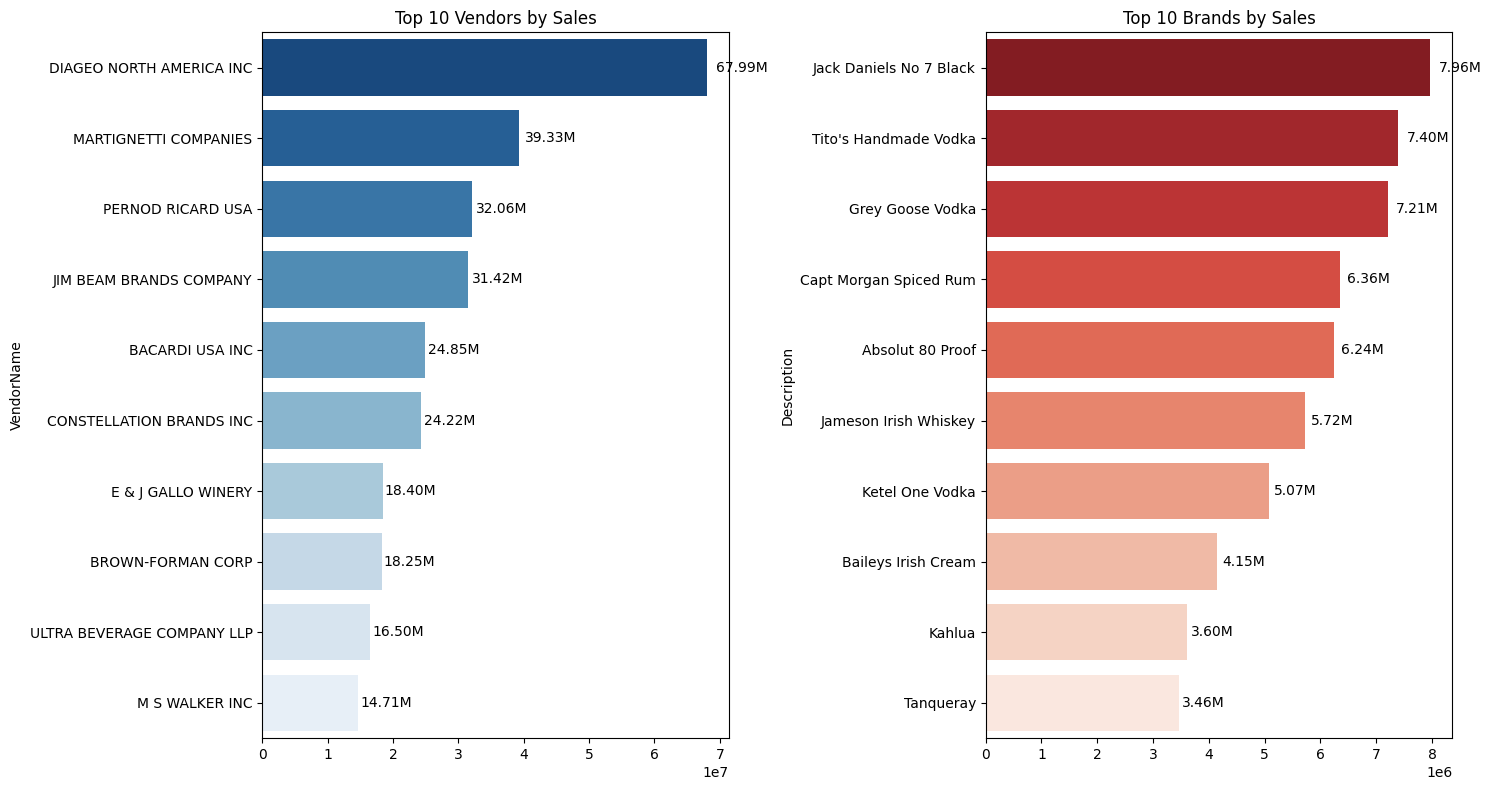

In [27]:
plt.figure(figsize=(15,8))

# Plot for Top Vendors
plt.subplot(1, 2, 1)
ax1 = sns.barplot(y=top_vendors.index, x=top_vendors.values, palette="Blues_r")
plt.title("Top 10 Vendors by Sales")

for bar in ax1.patches:
    ax1.text(bar.get_width() + (bar.get_width() * 0.02),
             bar.get_y() + bar.get_height() / 2,
             format_dollars(bar.get_width()),
             ha='left', va='center', fontsize=10, color='black')

# Plot for Top Brands
plt.subplot(1, 2, 2)
ax2 = sns.barplot(y=top_brands.index, x=top_brands.values, palette="Reds_r")
plt.title("Top 10 Brands by Sales")

for bar in ax2.patches:
    ax2.text(bar.get_width() + (bar.get_width() * 0.02),
             bar.get_y() + bar.get_height() / 2,
             format_dollars(bar.get_width()),
             ha='left', va='center', fontsize=10, color='black')
plt.tight_layout() 
plt.show()


In [ ]:
####

#### Which Vendors Contribute  the most to total purchase dollars

In [28]:
Vendore_performance=df.groupby("VendorName").agg({"TotalPurchaseDollars" :"sum",
"GrossProfit": "sum",
"TotalSalesDollars" :"sum" }).reset_index()

In [29]:
Vendore_performance["PurchaseContributionin%"]=round(Vendore_performance["TotalPurchaseDollars"] / Vendore_performance["TotalPurchaseDollars"].sum(),2)

In [30]:
top_vendors=Vendore_performance.sort_values("PurchaseContributionin%", ascending=False).nlargest(10,"PurchaseContributionin%")


In [31]:
top_vendors["TotalPurchaseDollars"]=top_vendors["TotalPurchaseDollars"].apply(format_dollars)
top_vendors["GrossProfit"]=top_vendors["GrossProfit"].apply(format_dollars)


In [32]:
top_vendors["TotalSalesDollars"]=top_vendors["TotalSalesDollars"].apply(format_dollars)


In [33]:
top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContributionin%
25,DIAGEO NORTH AMERICA INC,50.10M,17.89M,67.99M,0.16
46,JIM BEAM BRANDS COMPANY,23.49M,7.93M,31.42M,0.08
57,MARTIGNETTI COMPANIES,25.50M,13.83M,39.33M,0.08
68,PERNOD RICARD USA,23.85M,8.21M,32.06M,0.08
6,BACARDI USA INC,17.43M,7.42M,24.85M,0.06
20,CONSTELLATION BRANDS INC,15.27M,8.95M,24.22M,0.05
30,E & J GALLO WINERY,12.07M,6.33M,18.40M,0.04
11,BROWN-FORMAN CORP,13.24M,5.01M,18.25M,0.04
106,ULTRA BEVERAGE COMPANY LLP,11.17M,5.34M,16.50M,0.04
61,MOET HENNESSY USA INC,9.25M,4.11M,13.36M,0.03


In [34]:
top_vendors["PurchaseContributionin%"].sum()

np.float64(0.6600000000000001)

that means mainly top 10 vendores is contributing 66 percent to total purchase dollar

In [35]:
top_vendors["Comulative_Contribution%"]=top_vendors["PurchaseContributionin%"].cumsum()

In [36]:
top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContributionin%,Comulative_Contribution%
25,DIAGEO NORTH AMERICA INC,50.10M,17.89M,67.99M,0.16,0.16
46,JIM BEAM BRANDS COMPANY,23.49M,7.93M,31.42M,0.08,0.24
57,MARTIGNETTI COMPANIES,25.50M,13.83M,39.33M,0.08,0.32
68,PERNOD RICARD USA,23.85M,8.21M,32.06M,0.08,0.40
6,BACARDI USA INC,17.43M,7.42M,24.85M,0.06,0.46
20,CONSTELLATION BRANDS INC,15.27M,8.95M,24.22M,0.05,0.51
30,E & J GALLO WINERY,12.07M,6.33M,18.40M,0.04,0.55
11,BROWN-FORMAN CORP,13.24M,5.01M,18.25M,0.04,0.59
106,ULTRA BEVERAGE COMPANY LLP,11.17M,5.34M,16.50M,0.04,0.63
61,MOET HENNESSY USA INC,9.25M,4.11M,13.36M,0.03,0.66


C:\Users\ASUS\AppData\Local\Temp\ipykernel_21776\39198567.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_vendors['VendorName'], y=top_vendors['PurchaseContributionin%'],
C:\Users\ASUS\AppData\Local\Temp\ipykernel_21776\39198567.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(top_vendors['VendorName'], rotation=90)


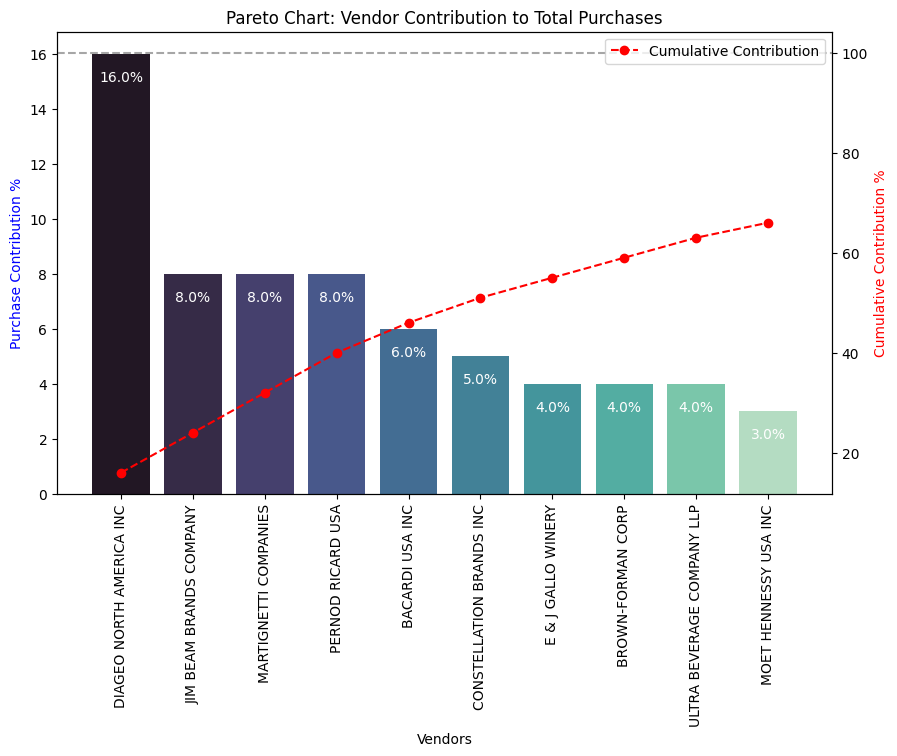

In [37]:
# Convert to percentage (if values are in decimals)
top_vendors['PurchaseContributionin%'] = top_vendors['PurchaseContributionin%'] * 100  

# Calculate Cumulative Contribution
top_vendors['Cumulative_Contribution%'] = top_vendors['PurchaseContributionin%'].cumsum()

fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar plot for Purchase Contribution%
sns.barplot(x=top_vendors['VendorName'], y=top_vendors['PurchaseContributionin%'], 
            palette="mako", ax=ax1)

for i, value in enumerate(top_vendors['PurchaseContributionin%']):
    ax1.text(i, value - 1, f"{value:.1f}%", ha='center', fontsize=10, color='white')

# Line Plot for Cumulative Contribution%
ax2 = ax1.twinx()
ax2.plot(top_vendors['VendorName'], top_vendors['Cumulative_Contribution%'], 
         color='red', marker='o', linestyle='dashed', label='Cumulative Contribution')

ax1.set_xticklabels(top_vendors['VendorName'], rotation=90)
ax1.set_ylabel('Purchase Contribution %', color='blue')
ax2.set_ylabel('Cumulative Contribution %', color='red')
ax1.set_xlabel('Vendors')
ax1.set_title('Pareto Chart: Vendor Contribution to Total Purchases')

ax2.axhline(y=100, color='gray', linestyle='dashed', alpha=0.7)
ax2.legend(loc='upper right')


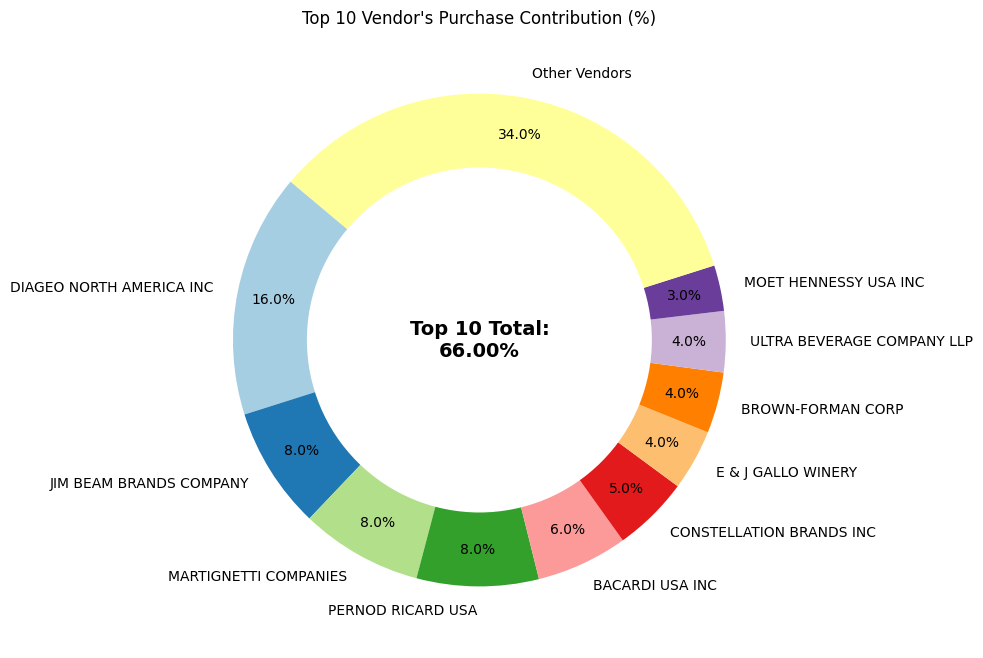

In [42]:
vendors = list(top_vendors['VendorName'].values)
purchase_contributions = list(top_vendors['PurchaseContributionin%'].values)
total_contribution = sum(purchase_contributions)
remaining_contribution = 100 - total_contribution

# Append "Other Vendors" category
vendors.append("Other Vendors")
purchase_contributions.append(remaining_contribution)

# Donut Chart
fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(
    purchase_contributions,
    labels=vendors,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.85,
    colors=plt.cm.Paired.colors
)

# Draw a white circle in the center to create a "donut" effect
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)

# Add Total Contribution annotation in the center
plt.text(
    0, 0, 
    f"Top 10 Total:\n{total_contribution:.2f}%", 
    fontsize=14, 
    fontweight='bold', 
    ha='center', 
    va='center'
)

plt.title("Top 10 Vendor's Purchase Contribution (%)")
plt.show()


#### Does Purchasing in bulk Reduce the unit price, and What is the optional Purchase Volume For Cost Saving ?

In [38]:
df["UnitPurchasePrice"]=df["TotalPurchaseDollars"]/df["TotalPurchaseQuantity"]

In [39]:
df

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio,UnitPurchasePrice
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,5101919.51,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647,26.27
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4819073.49,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830,23.19
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,4538120.60,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594,18.24
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,4475972.88,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493,16.17
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,4223107.62,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897,21.89
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8559,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,4.99,750.0,2,2.64,5.0,15.95,10.96,0.55,27100.41,13.31,83.448276,2.500000,6.041667,1.32
8560,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50.0,6,2.34,134.0,65.66,1.47,7.04,50293.62,63.32,96.436186,22.333333,28.059829,0.39
8561,3924,HEAVEN HILL DISTILLERIES,9123,Deep Eddy Vodka,0.74,0.99,50.0,2,1.48,2.0,1.98,0.99,0.10,14069.87,0.50,25.252525,1.000000,1.337838,0.74
8562,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.47,1.99,200.0,1,1.47,72.0,143.28,77.61,15.12,257032.07,141.81,98.974037,72.000000,97.469388,1.47


In [40]:
df["OrderSize"]=pd.qcut(df["TotalPurchaseQuantity"],q=3,labels=["Small","Medium","large"])

In [41]:
df[["OrderSize","TotalPurchaseQuantity"]]

,OrderSize,TotalPurchaseQuantity
0,large,145080
1,large,164038
2,large,187407
3,large,201682
4,large,138109
...,...,...
8559,Small,2
8560,Small,6
8561,Small,2
8562,Small,1


In [42]:
OrderSizeUnitPrice=df.groupby("OrderSize")[["UnitPurchasePrice"]].mean()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_21776\2581271513.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  OrderSizeUnitPrice=df.groupby("OrderSize")[["UnitPurchasePrice"]].mean()


In [44]:
OrderSizeUnitPrice

,UnitPurchasePrice
OrderSize,
Small,39.068186
Medium,15.486414
large,10.777625


C:\Users\ASUS\AppData\Local\Temp\ipykernel_21776\4205619139.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


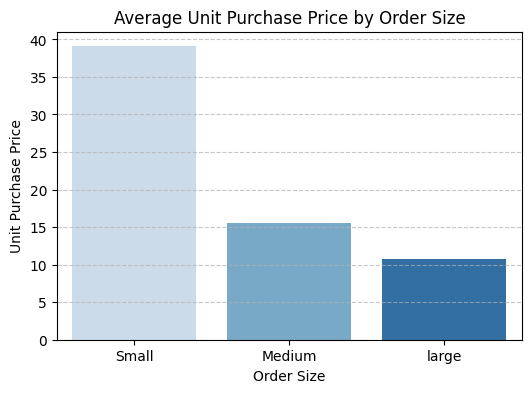

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

# Maan lo tumhara DataFrame hai OrderSizeUnitPrice (index = OrderSize)
# Index ko column me convert karo
df_plot = OrderSizeUnitPrice.reset_index()

plt.figure(figsize=(6,4))
sns.barplot(
    data=df_plot,
    x='OrderSize',
    y='UnitPurchasePrice',
    palette='Blues'   # color palette
)

plt.title("Average Unit Purchase Price by Order Size")
plt.xlabel("Order Size")
plt.ylabel("Unit Purchase Price")
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()


* Vendors buying in bulk (Large Order Size) get the lowest unit price ($10.78 per unit),  meaning higher margins if they can manage inventory efficiently.

* The price difference between Small and Large orders is substantial (~72% reduction in unit cost).

* This suggests that bulk pricing strategies successfully encourage vendors to purchase in larger volumes, leading to higher overall sales despite lower per-unit revenue.

In [46]:
LowStockTurnOver= df[df["StockTurnover"]<1].groupby("VendorName")[["StockTurnover"]].mean().sort_values('StockTurnover',ascending=True).head(10)

In [47]:
LowStockTurnOver.reset_index()

,VendorName,StockTurnover
0,ALISA CARR BEVERAGES,0.615385
1,HIGHLAND WINE MERCHANTS LLC,0.708333
2,PARK STREET IMPORTS LLC,0.751306
3,Circa Wines,0.755676
4,Dunn Wine Brokers,0.766022
5,CENTEUR IMPORTS LLC,0.773953
6,SMOKY QUARTZ DISTILLERY LLC,0.783835
7,TAMWORTH DISTILLING,0.797078
8,THE IMPORTED GRAPE LLC,0.807569
9,WALPOLE MTN VIEW WINERY,0.820548


C:\Users\ASUS\AppData\Local\Temp\ipykernel_20844\2912032245.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=LowStockTurnOver ,x= "StockTurnover",y="VendorName",palette="viridis")


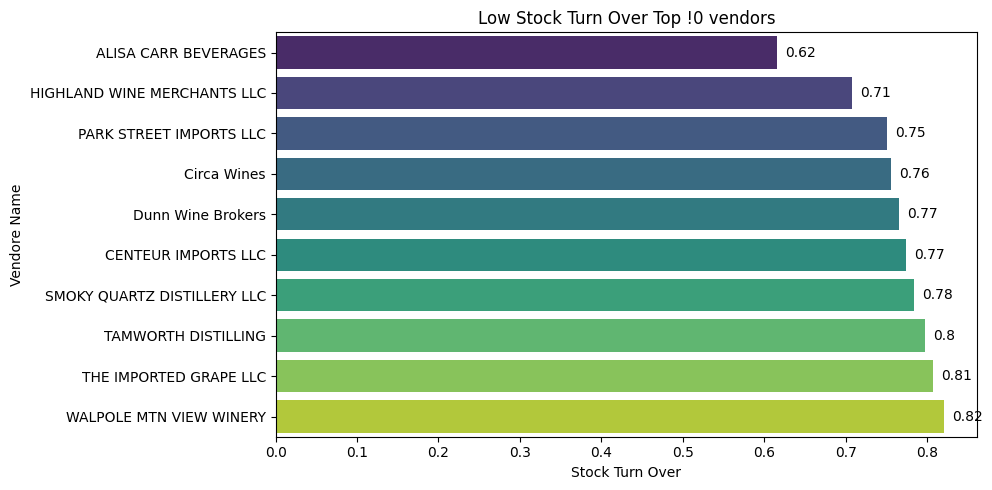

In [56]:
plt.figure(figsize=(10,5))
sns.barplot(data=LowStockTurnOver ,x= "StockTurnover",y="VendorName",palette="viridis")
for index, value in enumerate(LowStockTurnOver["StockTurnover"]):
    plt.text(value + 0.01, index, round(value, 2), va="center")

plt.title("Low Stock Turn Over Top !0 vendors")
plt.xlabel("Stock Turn Over")
plt.ylabel("Vendore Name")
plt.tight_layout()
plt.show()

#### How Much capitalIs locked in unsold inventory per vendor , which vendors contribute the most of it ?

In [48]:
df["UnsoldInventoryValue"]=(df["TotalPurchaseQuantity"]-df["TotalSalesQuantity"])*df["PurchasePrice"]

In [49]:
print("Total Unsold Capital",format_dollars(df["UnsoldInventoryValue"].sum()))

Total Unsold Capital 2.71M


In [50]:
inventry_value_per_vendor=df.groupby("VendorName")["UnsoldInventoryValue"].sum().reset_index()

inventry_value_per_vendor=inventry_value_per_vendor.sort_values("UnsoldInventoryValue",ascending=False)
inventry_value_per_vendor["UnsoldInventoryValue"]=inventry_value_per_vendor["UnsoldInventoryValue"].apply(format_dollars)
inventry_value_per_vendor.head(10)

#top 10 unsolode inventory vendores

,VendorName,UnsoldInventoryValue
25,DIAGEO NORTH AMERICA INC,722.21K
46,JIM BEAM BRANDS COMPANY,554.67K
68,PERNOD RICARD USA,470.63K
116,WILLIAM GRANT & SONS INC,401.96K
30,E & J GALLO WINERY,228.28K
79,SAZERAC CO INC,198.44K
11,BROWN-FORMAN CORP,177.73K
20,CONSTELLATION BRANDS INC,133.62K
61,MOET HENNESSY USA INC,126.48K
77,REMY COINTREAU USA INC,118.60K


#### What is the 95% confidence intervals for profit margins of top-performing and low-performing vendores .

In [56]:
top_threshold =df["TotalSalesDollars"].quantile(0.75)
low_threshold =df["TotalSalesDollars"].quantile(0.25)

In [57]:
top_threshold =df[df["TotalSalesDollars"]>=top_threshold]["ProfitMargin"].dropna()
low_threshold =df[df["TotalSalesDollars"]<= low_threshold]["ProfitMargin"].dropna()

In [58]:
top_threshold 

0       25.297693
1       21.062810
2       24.675786
3       27.139908
4       28.412764
          ...    
3523    79.684817
3681    85.782102
4751    93.085860
4920    95.012530
5050    94.271857
Name: ProfitMargin, Length: 2141, dtype: float64

In [54]:
low_threshold 

5631     4.111764
5652     6.145626
5701    12.007271
5704     1.677308
5724     7.239599
          ...    
8559    83.448276
8560    96.436186
8561    25.252525
8562    98.974037
8563    99.166079
Name: ProfitMargin, Length: 2141, dtype: float64

In [59]:
# Confidence interval function
def confidence_interval(data, confidence=0.95):
    mean_val = np.mean(data)
    std_err = np.std(data, ddof=1) / np.sqrt(len(data))  # Standard error
    t_critical = stats.t.ppf((1 + confidence) / 2, df=len(data) - 1)
    margin_of_error = t_critical * std_err
    return mean_val, mean_val - margin_of_error, mean_val + margin_of_error

# Calculate intervals
top_mean, top_lower, top_upper = confidence_interval(top_vendors)
low_mean, low_lower, low_upper = confidence_interval(low_vendors)

# Print results
print(f"Top Vendors 95% CI: ({top_lower:.2f}, {top_upper:.2f}), Mean: {top_mean:.2f}")
print(f"Low Vendors 95% CI: ({low_lower:.2f}, {low_upper:.2f}), Mean: {low_mean:.2f}")

plt.figure(figsize=(12, 6))

# Top Vendors Plot
sns.histplot(top_vendors, kde=True, color="blue", bins=30, alpha=0.5, label="Top Vendors")
plt.axvline(top_lower, color="blue", linestyle="--", label=f"Top Lower: {top_lower:.2f}")
plt.axvline(top_upper, color="blue", linestyle="--", label=f"Top Upper: {top_upper:.2f}")
plt.axvline(top_mean, color="blue", linestyle="-", label=f"Top Mean: {top_mean:.2f}")

# Low Vendors Plot
sns.histplot(low_vendors, kde=True, color="red", bins=30, alpha=0.5, label="Low Vendors")
plt.axvline(low_lower, color="red", linestyle="--", label=f"Low Lower: {low_lower:.2f}")
plt.axvline(low_upper, color="red", linestyle="--", label=f"Low Upper: {low_upper:.2f}")
plt.axvline(low_mean, color="red", linestyle="-", label=f"Low Mean: {low_mean:.2f}")

# Finalize Plot
plt.title("Confidence Interval Comparison: Top vs. Low Vendors (Profit Margin)")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()


TypeError: can only concatenate str (not "float") to str

Top Vendors 95% CI: (30.74, 31.61), Mean: 31.18
Low Vendors 95% CI: (40.50, 42.64), Mean: 41.57


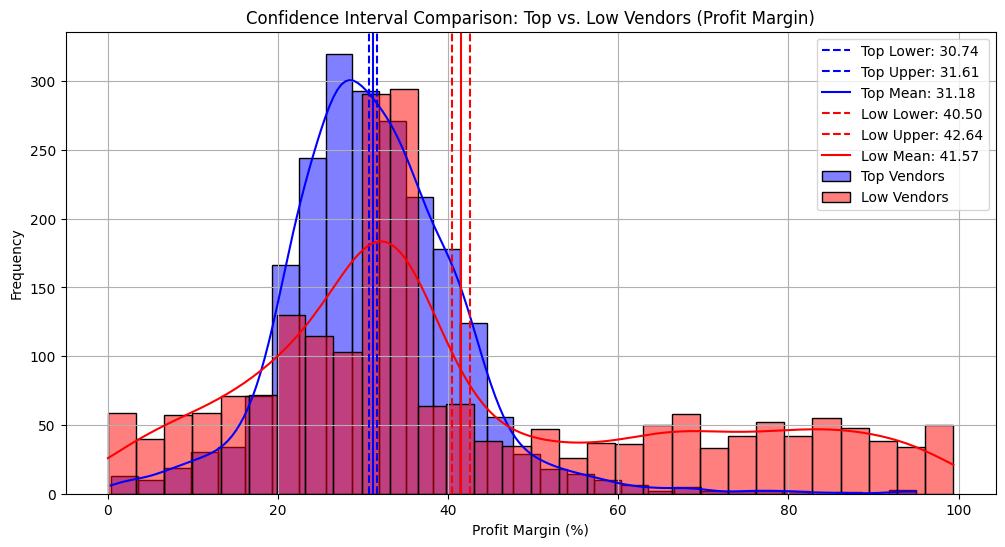

In [73]:
from scipy import stats        # <— this is the missing one

# thresholds
top_threshold = df["TotalSalesDollars"].quantile(0.75)
low_threshold = df["TotalSalesDollars"].quantile(0.25)

top_vendors = df[df["TotalSalesDollars"] >= top_threshold]["ProfitMargin"].dropna()
low_vendors = df[df["TotalSalesDollars"] <= low_threshold]["ProfitMargin"].dropna()

# Confidence interval function
def confidence_interval(data, confidence=0.95):
    mean_val = np.mean(data)
    std_err = np.std(data, ddof=1) / np.sqrt(len(data))  # Standard error
    t_critical = stats.t.ppf((1 + confidence) / 2, df=len(data) - 1)
    margin_of_error = t_critical * std_err
    return mean_val, mean_val - margin_of_error, mean_val + margin_of_error

# Calculate intervals
top_mean, top_lower, top_upper = confidence_interval(top_vendors)
low_mean, low_lower, low_upper = confidence_interval(low_vendors)

# Print results
print(f"Top Vendors 95% CI: ({top_lower:.2f}, {top_upper:.2f}), Mean: {top_mean:.2f}")
print(f"Low Vendors 95% CI: ({low_lower:.2f}, {low_upper:.2f}), Mean: {low_mean:.2f}")

plt.figure(figsize=(12, 6))

# Top Vendors Plot
sns.histplot(top_vendors, kde=True, color="blue", bins=30, alpha=0.5, label="Top Vendors")
plt.axvline(top_lower, color="blue", linestyle="--", label=f"Top Lower: {top_lower:.2f}")
plt.axvline(top_upper, color="blue", linestyle="--", label=f"Top Upper: {top_upper:.2f}")
plt.axvline(top_mean, color="blue", linestyle="-", label=f"Top Mean: {top_mean:.2f}")

# Low Vendors Plot
sns.histplot(low_vendors, kde=True, color="red", bins=30, alpha=0.5, label="Low Vendors")
plt.axvline(low_lower, color="red", linestyle="--", label=f"Low Lower: {low_lower:.2f}")
plt.axvline(low_upper, color="red", linestyle="--", label=f"Low Upper: {low_upper:.2f}")
plt.axvline(low_mean, color="red", linestyle="-", label=f"Low Mean: {low_mean:.2f}")

# Finalize Plot
plt.title("Confidence Interval Comparison: Top vs. Low Vendors (Profit Margin)")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()


### Confidence Interval (CI):

* Low-performing vendors: 40.48% to 42.62%

* Top-performing vendors: 30.74% to 31.61%

### Interpretations:

* Vendors with lower sales tend to maintain higher profit margins, likely due to premium pricing or lower operational costs.

* High-performing vendors could improve profitability by exploring selective price adjustments, cost optimization, or bundling strategies.

* Low-performing vendors: despite higher margins, their low sales volume might indicate a need for better marketing, competitive pricing, or improved distribution strategies.

#### Is there a significant difference in profit margins between top-performing and low-performing vendors?

##### Hypothesis:

* H₀ (Null Hypothesis): There is no significant difference in the mean profit margins of top-performing and low-performing vendors.


* H₁ (Alternative Hypothesis): The mean profit margins of top-performing and low-performing vendors are significantly different.


In [75]:
from scipy.stats import ttest_ind

# Perform Two-Sample T-Test
t_stat, p_value = ttest_ind(top_vendors, low_vendors, equal_var=False)

# Print results
print(f"T-Statistic: {t_stat:.4f}, P-Value: {p_value:.4f}")
if p_value < 0.05:
    print("Reject H₀: There is a significant difference in profit margins between top and low-performing vendors.")
else:
    print("Fail to Reject H₀: No significant difference in profit margins.")


T-Statistic: -17.6695, P-Value: 0.0000
Reject H₀: There is a significant difference in profit margins between top and low-performing vendors.
